# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import copy
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, get_free_cells, sample_goals)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html, plot_min_steps_and_min_time
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, contrastive_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
class FactorisedDQN_QNetwork(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int = 2,
        hidden_dim: int = 128,
        rep_dim: int = 64,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions
        self.goal_dim = goal_dim
        self.rep_dim = rep_dim

        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + self.action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        psi = self.goal_encoder(goal)
        psi = F.normalize(psi, p=2, dim=-1, eps=1e-8)
        return psi

    def encode_state_action(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        sa = torch.cat([obs, act], dim=-1)
        phi = self.sa_encoder(sa)
        phi = F.normalize(phi, p=2, dim=-1, eps=1e-8)
        return phi

    def forward(
        self,
        obs: torch.Tensor,
        act: torch.Tensor,
        goal: torch.Tensor,
    ) -> torch.Tensor:
        phi_sa = self.encode_state_action(obs, act)      # [B, D]
        psi_z = self.encode_goal(goal)                   # [B, D]
        q_vals = (phi_sa * psi_z).sum(dim=-1, keepdim=True)  # [B, 1]
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                        # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)   # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)             # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)          # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim)    # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat)    # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)                 # [B, A, D]

        psi_z = self.encode_goal(goal)                           # [B, D]
        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)           # [B, A, D]

        q_vals = (phi_sa * psi_rep).sum(dim=-1)                 # [B, A]
        return q_vals
    
    def forward_with_task_embedding(
        self,
        obs: torch.Tensor,
        act: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q(obs, act | psi) directly from a provided task embedding.

        obs: [B, obs_dim]
        act: [B, action_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        """
        phi_sa = self.encode_state_action(obs, act)  # [B, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(obs.shape[0], -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        q_vals = (phi_sa * psi_z).sum(dim=-1, keepdim=True)   # [B, 1]
        return q_vals
    
    def q_val_for_argmax_action_from_embedding(
        self,
        obs: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q-values for all actions using a provided task embedding.

        obs: [B, obs_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        returns: [B, A]
        """
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                             # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)  # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)          # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)       # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim) # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat) # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)              # [B, A, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(B, -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)         # [B, A, D]
        q_vals = (phi_sa * psi_rep).sum(dim=-1)               # [B, A]
        return q_vals

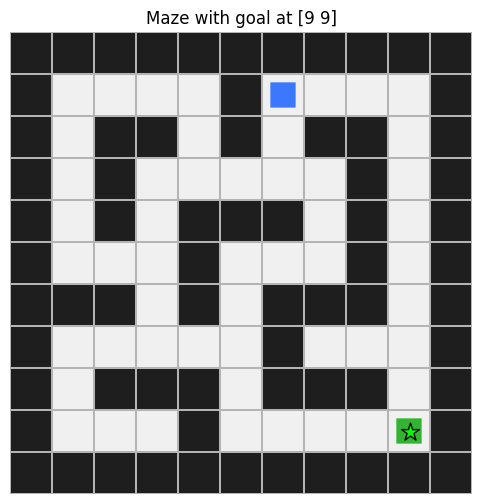

In [3]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

class NextStateEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 128, rep_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, next_obs: torch.Tensor) -> torch.Tensor:
        z = self.net(next_obs)
        z = F.normalize(z, dim=-1)
        return z

In [ ]:

def dqn_train_dot_head_online(
    seed=42,
    q_network=None,
    q_target_network=None,
    next_state_encoder=None,
    next_state_target_encoder=None,
    env=None,
    buffer_capacity=None,
    obs_dim=None,
    device=None,
    total_steps=150_000,
    warmup_steps=5_000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=100_000,
    train_freq=4,
    goal=None,
    td_steps=1,
    make_env=None,
    lr_sa=5e-4,
    lr_ns=1e-3,
    lr_goal=1e-3,
    dyn_temperature=0.1,
    dyn_coef=1.0,
    sigreg_coef=0.0,
    ns_target_momentum=0.995,
    bootstrap_on_truncation=True,
    sa_td_coef=0.0,
    grad_clip_norm=10.0,
    early_stop_reward=0.99,
    early_stop_patience=5,
    enable_early_stop=True,
):
    """
    Q(s, a, g) = phi(s, a)^T psi(g)

    Goal encoder:
        Updated from Bellman TD loss.

    SA encoder:
        Updated from a task-agnostic contrastive dynamics objective.
        With sa_td_coef=0, it receives no task/goal TD gradient.
    """
    if q_network is None:
        raise ValueError("q_network must be provided")
    if q_target_network is None:
        raise ValueError("q_target_network must be provided")
    if next_state_encoder is None:
        raise ValueError("next_state_encoder must be provided")
    if env is None:
        raise ValueError("env must be provided")
    if buffer_capacity is None:
        raise ValueError("buffer_capacity must be provided")
    if goal is None:
        raise ValueError("goal must be provided")
    if make_env is None:
        raise ValueError("make_env must be provided")

    if device is None:
        device = next(q_network.parameters()).device

    if obs_dim is None:
        obs_dim = int(env.observation_space.shape[0])

    set_seed(seed)
    num_actions = env.action_space.n

    q_network = q_network.to(device)
    q_target_network = q_target_network.to(device)
    next_state_encoder = next_state_encoder.to(device)

    # ---------------------------------------------------------
    # Frozen DQN target network
    # ---------------------------------------------------------

    q_target_network.load_state_dict(q_network.state_dict())
    q_target_network.eval()

    for parameter in q_target_network.parameters():
        parameter.requires_grad_(False)

    # ---------------------------------------------------------
    # EMA target for contrastive next-state embeddings
    # ---------------------------------------------------------

    if next_state_target_encoder is None:
        next_state_target_encoder = copy.deepcopy(
            next_state_encoder
        )

    next_state_target_encoder = next_state_target_encoder.to(device)
    next_state_target_encoder.load_state_dict(
        next_state_encoder.state_dict()
    )
    next_state_target_encoder.eval()

    for parameter in next_state_target_encoder.parameters():
        parameter.requires_grad_(False)

    # ---------------------------------------------------------
    # Optimisers: separate gradient ownership
    # ---------------------------------------------------------

    opt_goal = optim.Adam(
        q_network.goal_encoder.parameters(),
        lr=lr_goal,
    )

    opt_dynamics = optim.Adam(
        [
            {
                "params": q_network.sa_encoder.parameters(),
                "lr": lr_sa,
            },
            {
                "params": next_state_encoder.parameters(),
                "lr": lr_ns,
            },
        ]
    )

    # ---------------------------------------------------------
    # Replay and current goal
    # ---------------------------------------------------------

    buffer = TrajectoryReplayBufferDiscrete(
        buffer_capacity,
        obs_dim,
        1,
        device=device,
    )

    goal_t_single = torch.as_tensor(
        np.asarray(goal, dtype=np.float32),
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    obs, _ = env.reset()

    global_step = 0
    success_streak = 0
    start_time = time.perf_counter()

    eval_returns = []
    eval_returns_time = []

    min_steps = None
    min_time = None

    td_loss = torch.zeros((), device=device)
    td_sa_loss = torch.zeros((), device=device)
    contrastive_loss_value = torch.zeros((), device=device)
    sigreg_loss_value = torch.zeros((), device=device)
    dynamics_loss = torch.zeros((), device=device)
    all_logits = None

    q_network.train()
    next_state_encoder.train()

    # ---------------------------------------------------------
    # Helpers
    # ---------------------------------------------------------

    def compute_td_target(
        next_obs_t,
        rew_t,
        terminated_t,
        truncated_t,
        goal_batch,
    ):
        with torch.no_grad():
            next_q_values = q_target_network.q_val_for_argmax_action(
                next_obs_t,
                goal_batch,
            )

            next_q = next_q_values.max(
                dim=-1,
                keepdim=True,
            ).values

            if bootstrap_on_truncation:
                bootstrap_mask = 1.0 - terminated_t
            else:
                done_t = torch.clamp(
                    terminated_t + truncated_t,
                    min=0.0,
                    max=1.0,
                )
                bootstrap_mask = 1.0 - done_t

            return rew_t + (
                gamma ** td_steps
            ) * bootstrap_mask * next_q

    @torch.no_grad()
    def update_targets():
        for online_parameter, target_parameter in zip(
            q_network.parameters(),
            q_target_network.parameters(),
        ):
            target_parameter.mul_(1.0 - tau).add_(
                tau * online_parameter
            )

        for online_parameter, target_parameter in zip(
            next_state_encoder.parameters(),
            next_state_target_encoder.parameters(),
        ):
            target_parameter.mul_(
                ns_target_momentum
            ).add_(
                (1.0 - ns_target_momentum)
                * online_parameter
            )

    # ---------------------------------------------------------
    # Main loop
    # ---------------------------------------------------------

    while global_step < total_steps:

        fraction = min(
            1.0,
            global_step / max(1, eps_decay_steps),
        )

        epsilon = eps_start + fraction * (
            eps_end - eps_start
        )

        # -----------------------------------------------------
        # Data collection
        # -----------------------------------------------------

        if np.random.random() < epsilon:
            action = env.action_space.sample()

        else:
            obs_single = torch.as_tensor(
                obs,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)

            with torch.no_grad():
                q_values = q_network.q_val_for_argmax_action(
                    obs_single,
                    goal_t_single,
                )

            action = int(q_values.argmax(dim=-1).item())

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Important: preserve terminated AND truncated separately.
        buffer.add_transition(
            obs,
            action,
            reward,
            next_obs,
            terminated,
            truncated,
        )

        obs = next_obs
        global_step += 1

        if done:
            obs, _ = env.reset()

        # -----------------------------------------------------
        # Training
        # -----------------------------------------------------

        if (
            len(buffer) < warmup_steps
            or global_step % train_freq != 0
        ):
            continue

        batch = buffer.sample(batch_size)

        obs_t = batch.obs
        actions_t = batch.actions.long().view(-1)
        rewards_t = batch.rewards
        next_obs_t = batch.next_obs
        terminated_t = batch.terminated.float()
        truncated_t = batch.truncated.float()

        if rewards_t.ndim == 1:
            rewards_t = rewards_t.unsqueeze(-1)

        if terminated_t.ndim == 1:
            terminated_t = terminated_t.unsqueeze(-1)

        if truncated_t.ndim == 1:
            truncated_t = truncated_t.unsqueeze(-1)

        batch_size_actual = obs_t.shape[0]

        action_onehot = F.one_hot(
            actions_t,
            num_classes=num_actions,
        ).float()

        goal_batch = goal_t_single.expand(
            batch_size_actual,
            -1,
        )

        target = compute_td_target(
            next_obs_t,
            rewards_t,
            terminated_t,
            truncated_t,
            goal_batch,
        )

        # =====================================================
        # 1. Goal encoder TD update
        #
        # phi is detached: no TD gradient reaches SA encoder.
        # =====================================================

        with torch.no_grad():
            phi_fixed = q_network.encode_state_action(
                obs_t,
                action_onehot,
            )

        goal_embedding = q_network.encode_goal(goal_batch)

        current_q_goal = (
            phi_fixed * goal_embedding
        ).sum(
            dim=-1,
            keepdim=True,
        )

        assert current_q_goal.shape == target.shape, (
            current_q_goal.shape,
            target.shape,
        )

        td_loss = F.smooth_l1_loss(
            current_q_goal,
            target,
        )

        opt_goal.zero_grad(set_to_none=True)
        td_loss.backward()

        nn.utils.clip_grad_norm_(
            q_network.goal_encoder.parameters(),
            grad_clip_norm,
        )

        opt_goal.step()

        # =====================================================
        # 2. SA + next-state dynamics update
        #
        # No goal representation appears in contrastive loss.
        # =====================================================

        phi_sa = q_network.encode_state_action(
            obs_t,
            action_onehot,
        )

        with torch.no_grad():
            next_features = next_state_target_encoder(
                next_obs_t
            )

        # Row i should match next-state representation i.
        all_logits = phi_sa @ next_features.T

        labels = torch.arange(
            batch_size_actual,
            device=device,
        )

        contrastive_loss_value = F.cross_entropy(
            all_logits / dyn_temperature,
            labels,
        )

        if sigreg_coef > 0.0:
            sigreg_loss_value = sigreg_loss(phi_sa)
        else:
            sigreg_loss_value = torch.zeros(
                (),
                device=device,
            )

        dynamics_loss = (
            dyn_coef * contrastive_loss_value
            + sigreg_coef * sigreg_loss_value
        )

        # Optional control-aware SA ablation.
        # Keep sa_td_coef=0.0 for task-agnostic SA learning.
        if sa_td_coef > 0.0:

            with torch.no_grad():
                goal_embedding_fixed = q_network.encode_goal(
                    goal_batch
                )

            current_q_sa = (
                phi_sa * goal_embedding_fixed
            ).sum(
                dim=-1,
                keepdim=True,
            )

            assert current_q_sa.shape == target.shape

            td_sa_loss = F.smooth_l1_loss(
                current_q_sa,
                target,
            )

        else:
            td_sa_loss = torch.zeros(
                (),
                device=device,
            )

        sa_loss = dynamics_loss + sa_td_coef * td_sa_loss

        opt_dynamics.zero_grad(set_to_none=True)
        sa_loss.backward()

        nn.utils.clip_grad_norm_(
            q_network.sa_encoder.parameters(),
            grad_clip_norm,
        )

        nn.utils.clip_grad_norm_(
            next_state_encoder.parameters(),
            grad_clip_norm,
        )

        opt_dynamics.step()

        # =====================================================
        # 3. Update frozen target networks
        # =====================================================

        update_targets()

        # -----------------------------------------------------
        # Evaluation
        # -----------------------------------------------------

        if global_step % 1000 != 0:
            continue

        q_network.eval()

        eval_env = make_env(goal)

        def eval_policy(observation):
            observation_t = torch.as_tensor(
                observation,
                dtype=torch.float32,
                device=device,
            ).unsqueeze(0)

            with torch.no_grad():
                values = q_network.q_val_for_argmax_action(
                    observation_t,
                    goal_t_single,
                )

            return int(values.argmax(dim=-1).item())

        mean_return, mean_length = evaluate_policy(
            eval_env,
            eval_policy,
            episodes=8,
        )

        eval_time = time.perf_counter() - start_time

        eval_returns.append(
            (global_step, mean_return)
        )
        eval_returns_time.append(
            (eval_time, mean_return)
        )

        with torch.no_grad():
            if all_logits is not None and all_logits.shape[0] > 1:
                diagonal_mean = all_logits.diag().mean().item()

                off_diagonal_mean = (
                    all_logits.sum()
                    - all_logits.diag().sum()
                ) / (
                    all_logits.numel()
                    - all_logits.shape[0]
                )

                off_diagonal_mean = off_diagonal_mean.item()

            else:
                diagonal_mean = 0.0
                off_diagonal_mean = 0.0

        print(
            f"[DQN-task-agnostic] "
            f"step={global_step:7d} | "
            f"eps={epsilon:.3f} | "
            f"return={mean_return:.3f} | "
            f"len={mean_length:.1f} | "
            f"TD_goal={td_loss.item():.4e} | "
            f"TD_sa={td_sa_loss.item():.4e} | "
            f"InfoNCE={contrastive_loss_value.item():.4e} | "
            f"Dyn={dynamics_loss.item():.4e} | "
            f"diag={diagonal_mean:.3f} | "
            f"offdiag={off_diagonal_mean:.3f} | "
            f"SigReg={sigreg_loss_value.item():.4e} | "
            f"sa_td_coef={sa_td_coef:.2f}"
        )

        eval_env.close()
        q_network.train()

        if mean_return >= early_stop_reward:
            success_streak += 1
        else:
            success_streak = 0

        if (
            enable_early_stop
            and success_streak >= early_stop_patience
        ):
            min_steps = global_step
            min_time = eval_time

            print(
                f"Early stop at step={global_step}; "
                f"return={mean_return:.3f}; "
                f"streak={success_streak}."
            )

            break

    # ---------------------------------------------------------
    # Final outputs
    # ---------------------------------------------------------

    if min_steps is None:
        min_steps = global_step
        min_time = time.perf_counter() - start_time

    q_network.eval()

    with torch.no_grad():
        task_embedding = q_network.encode_goal(
            goal_t_single
        ).squeeze(0)

    task_embedding = task_embedding.cpu().numpy()

    obs_probe_np = np.array([5.0, 5.0], dtype=np.float32)

    base_env = (
        env.unwrapped
        if hasattr(env, "unwrapped")
        else env
    )

    action_names = getattr(
        base_env,
        "action_names",
        ["Up", "Down", "Left", "Right"],
    )

    act_probe_idx = action_names.index("Up")

    sa_embedding_mean = extract_mean_sa_embedding(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=256,
        device=device,
        as_numpy=True,
    )

    sa_embedding_fixed = extract_fixed_probe_sa_embedding(
        q_network=q_network,
        obs_probe=obs_probe_np,
        act_probe_idx=act_probe_idx,
        num_actions=num_actions,
        device=device,
        as_numpy=True,
    )

    sa_batch_final = extract_sa_batch_for_isotropy(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=1024,
        device=device,
        as_numpy=True,
    )

    env.close()

    return (
        q_network,
        q_target_network,
        next_state_encoder,
        next_state_target_encoder,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds

In [5]:
SEEDS = [42]

NUM_GOALS = 3
goal_rng = np.random.default_rng(0)

GOALS = sample_goals(
    NUM_GOALS,
    goal_rng,
    cells=get_free_cells(MAZE_LAYOUT),
)

print("Sampled GOALS:", GOALS)

BUFFER_CAPACITY = 100_000

LR_SA = 5e-4
LR_NS = 1e-3
LR_GOAL = 1e-3

TOTAL_STEPS = 100_000
WARMUP_STEPS = 5_000
BATCH_SIZE = 256

DYN_COEF = 1.0
DYN_TEMPERATURE = 0.1
SIGREG_COEF = 0.0

# Strict environment-feature experiment:
# SA receives zero goal-specific TD gradient.
SA_TD_COEF = 0.0

# EMA rate for the contrastive next-state target encoder.
NS_TARGET_MOMENTUM = 0.995


overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}


# ---------------------------------------------------------
# Sequential goals
# ---------------------------------------------------------

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")

    set_seed(seed)

    # -----------------------------------------------------
    # Infer environment dimensions once
    # -----------------------------------------------------

    env_tmp = make_env(goal=GOALS[0])

    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n

    env_tmp.close()

    # -----------------------------------------------------
    # Initial online and target Q networks
    # -----------------------------------------------------

    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target_base.load_state_dict(
        q_net_base.state_dict()
    )

    # -----------------------------------------------------
    # Shared online/EMA next-state encoders
    #
    # Both persist across goals. The online version is
    # trainable; the target is updated by EMA inside trainer.
    # -----------------------------------------------------

    next_state_encoder_base = NextStateEncoder(
        obs_dim=obs_dim,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    next_state_target_encoder_base = deepcopy(
        next_state_encoder_base
    ).to(DEVICE)

    for parameter in next_state_target_encoder_base.parameters():
        parameter.requires_grad_(False)

    # -----------------------------------------------------
    # Sequential state
    # -----------------------------------------------------

    prev_q_net = None
    prev_q_target = None
    prev_next_state_encoder = None
    prev_next_state_target_encoder = None

    task_embedding_memory = []
    seen_goal_labels = []

    weight_history = []

    # -----------------------------------------------------
    # Train one goal at a time
    # -----------------------------------------------------

    for goal_idx, goal in enumerate(GOALS):
        print(
            f"\n----- seed={seed}, "
            f"goal_idx={goal_idx}, goal={goal} -----\n"
        )

        if goal_idx == 0:
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)

            next_state_encoder = deepcopy(
                next_state_encoder_base
            )

            next_state_target_encoder = deepcopy(
                next_state_target_encoder_base
            )

        else:
            if any(
                item is None
                for item in [
                    prev_q_net,
                    prev_q_target,
                    prev_next_state_encoder,
                    prev_next_state_target_encoder,
                ]
            ):
                raise RuntimeError(
                    "Previous task state was not stored."
                )

            # Carry all learned environment structure forward.
            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)

            next_state_encoder = deepcopy(
                prev_next_state_encoder
            )

            next_state_target_encoder = deepcopy(
                prev_next_state_target_encoder
            )

        # Ensure the online network is initially mirrored by its
        # DQN target. The trainer will then use Polyak updates.
        q_target.load_state_dict(q_net.state_dict())

        # Safety: only online modules are trainable.
        for parameter in q_net.parameters():
            parameter.requires_grad_(True)

        for parameter in q_target.parameters():
            parameter.requires_grad_(False)

        for parameter in next_state_encoder.parameters():
            parameter.requires_grad_(True)

        for parameter in next_state_target_encoder.parameters():
            parameter.requires_grad_(False)

        # -------------------------------------------------
        # Optional parameter drift snapshot
        # -------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=(
                    f"goal_{goal_idx}_before_train_{goal}"
                ),
                sa_keywords_local=["sa_encoder"],
                goal_keywords_local=["goal_encoder"],
                max_samples_per_group=40_000,
            )
        )

        # -------------------------------------------------
        # Train current goal
        # -------------------------------------------------

        (
            q_network,
            q_target_network,
            next_state_encoder,
            next_state_target_encoder,
            eval_returns,
            eval_returns_time,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_dot_head_online(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            next_state_encoder=next_state_encoder,
            next_state_target_encoder=next_state_target_encoder,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=TOTAL_STEPS,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=80_000,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            lr_sa=LR_SA,
            lr_ns=LR_NS,
            lr_goal=LR_GOAL,
            dyn_temperature=DYN_TEMPERATURE,
            dyn_coef=DYN_COEF,
            sigreg_coef=SIGREG_COEF,
            ns_target_momentum=NS_TARGET_MOMENTUM,

            # For a Gymnasium time-limit, this is commonly True.
            # Set False if truncation denotes a real terminal
            # failure in your maze.
            bootstrap_on_truncation=True,

            # Crucial: 0 means the SA encoder gets no TD gradient.
            sa_td_coef=SA_TD_COEF,

            grad_clip_norm=10.0,
            early_stop_reward=0.99,
            early_stop_patience=5,
            enable_early_stop=True,
        )

        # -------------------------------------------------
        # Optional parameter drift snapshot
        # -------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=(
                    f"goal_{goal_idx}_after_train_{goal}"
                ),
                sa_keywords_local=["sa_encoder"],
                goal_keywords_local=["goal_encoder"],
                max_samples_per_group=40_000,
            )
        )

        # -------------------------------------------------
        # Current-task diagnostics
        # -------------------------------------------------

        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_network,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))

        print_goal_embedding_similarity(
            task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        # -------------------------------------------------
        # Carry all online and target modules forward
        # -------------------------------------------------

        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        prev_next_state_encoder = deepcopy(
            next_state_encoder
        )

        prev_next_state_target_encoder = deepcopy(
            next_state_target_encoder
        )

        # -------------------------------------------------
        # Store output statistics
        # -------------------------------------------------

        overall_results[goal]["eval_returns"].append(
            eval_returns
        )

        overall_results[goal]["eval_returns_time"].append(
            eval_returns_time
        )

        overall_results[goal]["min_steps"].append(
            min_steps
        )

        overall_results[goal]["min_time"].append(
            min_time
        )

        overall_results[goal]["task_embeddings"].append(
            task_embedding
        )

        overall_results[goal]["sa_embeddings"].append(
            sa_embedding_mean
        )

        overall_results[goal][
            "sa_fixed_probe_embeddings"
        ].append(
            sa_embedding_fixed
        )

        overall_results[goal]["sa_batches_final"].append(
            sa_batch_final
        )

Sampled GOALS: [(9, 6), (5, 5), (5, 8)]

================ SEED 42 ================


----- seed=42, goal_idx=0, goal=(9, 6) -----

[DQN-task-agnostic] step=   5000 | eps=0.941 | return=-9.912 | len=100.0 | TD_goal=4.5519e-03 | TD_sa=0.0000e+00 | InfoNCE=5.5008e+00 | Dyn=5.5008e+00 | diag=0.213 | offdiag=0.192 | SigReg=0.0000e+00 | sa_td_coef=0.00
[DQN-task-agnostic] step=   6000 | eps=0.929 | return=-6.000 | len=76.0 | TD_goal=1.7075e-03 | TD_sa=0.0000e+00 | InfoNCE=4.3754e+00 | Dyn=4.3754e+00 | diag=0.336 | offdiag=0.127 | SigReg=0.0000e+00 | sa_td_coef=0.00
[DQN-task-agnostic] step=   7000 | eps=0.917 | return=-8.662 | len=100.0 | TD_goal=5.1433e-03 | TD_sa=0.0000e+00 | InfoNCE=4.3005e+00 | Dyn=4.3005e+00 | diag=0.356 | offdiag=0.130 | SigReg=0.0000e+00 | sa_td_coef=0.00
[DQN-task-agnostic] step=   8000 | eps=0.905 | return=-7.312 | len=87.9 | TD_goal=2.8068e-03 | TD_sa=0.0000e+00 | InfoNCE=4.2714e+00 | Dyn=4.2714e+00 | diag=0.325 | offdiag=0.097 | SigReg=0.0000e+00 | sa_td_coef=0.00

KeyboardInterrupt: 

In [ ]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [ ]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_network, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        task_embedding = q_network.encode_goal(torch.tensor(goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy()
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_network, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])